<a href="https://colab.research.google.com/github/h-mutumwinka/Summative_MLPipeline/blob/main/Cifar10_mlops_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten,
    Input
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

/tmp/ipykernel_22206/2886995673.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


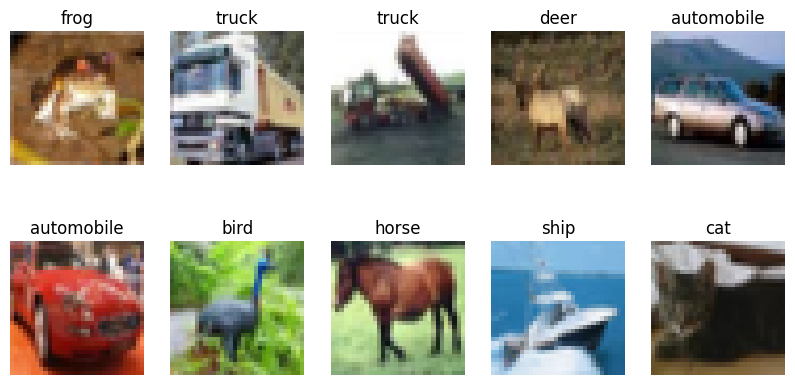

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.show()

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [6]:
model = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32,(3,3),activation="relu",padding="same"),
    BatchNormalization(),

    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64,(3,3),activation="relu",padding="same"),
    BatchNormalization(),

    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),

    Dense(256,activation="relu"),
    Dropout(0.50),

    Dense(10,activation="softmax")
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,


    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 352ms/step - accuracy: 0.3485 - loss: 1.7626 - val_accuracy: 0.4044 - val_loss: 1.6508
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 343ms/step - accuracy: 0.5018 - loss: 1.3763 - val_accuracy: 0.5301 - val_loss: 1.2614
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 350ms/step - accuracy: 0.5825 - loss: 1.1771 - val_accuracy: 0.5650 - val_loss: 1.1803
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 333ms/step - accuracy: 0.6360 - loss: 1.0439 - val_accuracy: 0.6591 - val_loss: 0.9571
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 329ms/step - accuracy: 0.6676 - loss: 0.9586 - val_accuracy: 0.7053 - val_loss: 0.8226
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 211s 337ms/step - accuracy: 0.6880 - loss: 0.8900 - val_accuracy: 0.7213 - val_loss: 0.7887
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 260s 334ms/step - accuracy: 0.7098 - loss: 0.8421 - val_accuracy: 0.7051 - val_loss: 0.8396
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 349ms/step - accuracy: 0.7206 -

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7795 - loss: 0.6583
Test Accuracy: 0.7795000076293945
Test Loss: 0.6583408713340759
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step


In [11]:
precision = precision_score(
    true_classes,
    predicted_classes,
    average="weighted",
)

recall = recall_score(
    true_classes,
    predicted_classes,
    average="weighted",
)

f1 = f1_score(
    true_classes,
    predicted_classes,
    average="weighted",
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7839318501870164
Recall: 0.7795
F1 Score: 0.7789056887180075


In [12]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
    )
)

              precision    recall  f1-score   support

    airplane       0.78      0.80      0.79      1000
  automobile       0.88      0.91      0.89      1000
        bird       0.71      0.65      0.68      1000
         cat       0.67      0.55      0.60      1000
        deer       0.69      0.81      0.74      1000
         dog       0.63      0.76      0.69      1000
        frog       0.85      0.82      0.83      1000
       horse       0.90      0.78      0.83      1000
        ship       0.83      0.91      0.87      1000
       truck       0.91      0.81      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



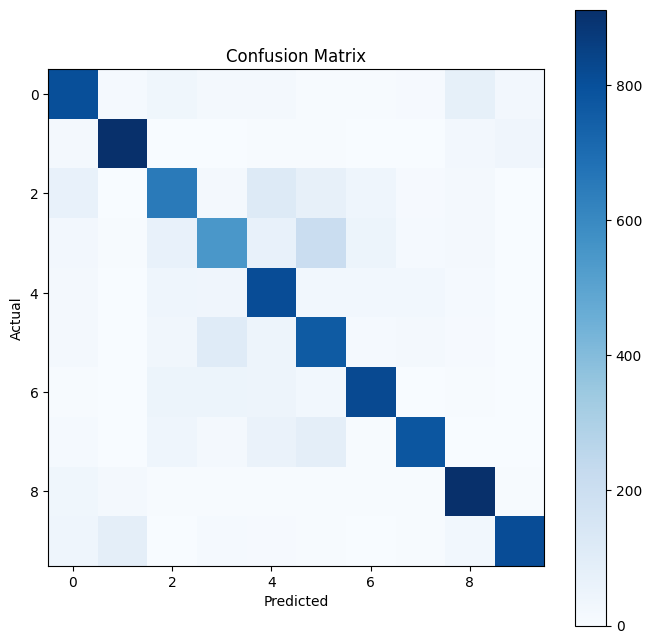

In [13]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

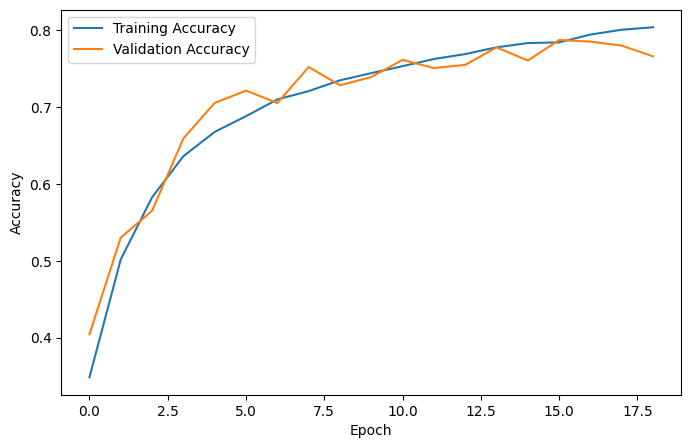

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

os.makedirs("../static/plots", exist_ok=True)
plt.savefig("../static/plots/accuracy.png")

plt.show()

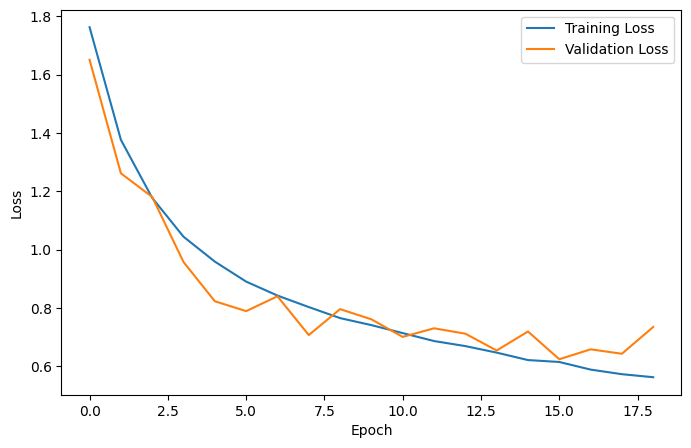

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../static/plots/loss.png")

plt.show()

In [16]:
os.makedirs("../models", exist_ok=True)

model.save("../models/cifar10_model.keras")

print("Model saved successfully!")

Model saved successfully!
